# Удержание и сегментация клиентов в электронной коммерции

## 📌 Бизнес-задача

Компания, занимающаяся онлайн-розничной торговлей, хочет понять покупательское поведение клиентов
и выявить возможности для увеличения повторных покупок.

Главный бизнес-вопрос:

> **Какие факторы связаны с повторными покупками, и на какие сегменты клиентов
> следует сосредоточиться для удержания и реактивации?**

## 🎯 Аналитические вопросы

Цель данного проекта — ответить на следующие вопросы:

1. Какой процент клиентов совершает более одной покупки?

2. Сколько времени обычно требуется клиенту для совершения второй покупки?

3. Как удержание клиентов различается в зависимости от когорт привлечения?

4. Связано ли поведение, связанное с первым заказом, с повторными покупками?

5. Какие сегменты клиентов приносят наибольший доход?

6. Какие сегменты клиентов могут быть актуальны для реактивации?

7. Существуют ли продукты или страны с необычно высоким уровнем отмен заказов?

## 📊 Набор данных

Набор данных содержит транзакционные данные онлайн-магазина.

Основные поля:

- `TransactionNo` — идентификатор транзакции
- `Date` — дата транзакции
- `ProductNo` — идентификатор товара
- `Product` — описание товара
- `Price` — цена за единицу
- `Quantity` — количество приобретенного товара
- `CustomerNo` — идентификатор клиента
- `Country` — страна клиента

Транзакции, в которых `TransactionNo` начинается с `C`, означают отмену.

---

## 🛠️ Инструменты

- **Python** — статистический анализ и визуализация
- **Pandas** — обработка данных
- **Matplotlib** — визуализация
- **SciPy** — статистическое тестирование

---

## 🔍 Структура анализа

1. Качество и подготовка данных
2. Метрики клиентов
3. Время до второй покупки
4. Анализ удержания когорт
5. Первая покупка и повторное поведение
6. RFM-сегментация клиентов
7. Анализ отмен заказов
8. Ключевые выводы и гипотезы о продукте

In [342]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency

# 1. Загрузка данных и первоначальное исследование

In [2]:
df = pd.read_csv('sales_transaction.csv')

In [3]:
df.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom


In [4]:
df.shape

(536350, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  536350 non-null  str    
 1   Date           536350 non-null  str    
 2   ProductNo      536350 non-null  str    
 3   ProductName    536350 non-null  str    
 4   Price          536350 non-null  float64
 5   Quantity       536350 non-null  int64  
 6   CustomerNo     536295 non-null  float64
 7   Country        536350 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 32.7 MB


In [6]:
df.isnull().sum()

TransactionNo     0
Date              0
ProductNo         0
ProductName       0
Price             0
Quantity          0
CustomerNo       55
Country           0
dtype: int64

In [7]:
df[df['CustomerNo'].isnull()].head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
6511,C581406,12/8/2019,46000M,Polyester Filler Pad 45x45cm,6.19,-240,NaN,United Kingdom
6512,C581406,12/8/2019,46000S,Polyester Filler Pad 40x40cm,6.19,-300,NaN,United Kingdom
90098,C575153,11/8/2019,22947,Wooden Advent Calendar Red,44.25,-1,NaN,United Kingdom
102671,C574288,11/3/2019,22178,Victorian Glass Hanging T-Light,25.37,-1,NaN,United Kingdom
117263,C573180,10/28/2019,23048,Set Of 10 Lanterns Fairy Light Star,14.50,-1,NaN,United Kingdom


In [8]:
na = df[df['CustomerNo'].isna()]
print(na['TransactionNo'].str.startswith('C').value_counts())

TransactionNo
True     54
False     1
Name: count, dtype: int64


55 строк имеют пропущенный CustomerNo. Из них 54 относятся к отменённым транзакциям, а 1 строка — к обычной транзакции. Поскольку дальнейший анализ посвящён клиентскому поведению, строки без идентификатора клиента исключаются.

In [9]:
df.dropna(subset='CustomerNo', inplace=True)

In [10]:
df.isnull().sum()

TransactionNo    0
Date             0
ProductNo        0
ProductName      0
Price            0
Quantity         0
CustomerNo       0
Country          0
dtype: int64

In [11]:
df['Date'] = pd.to_datetime(df['Date'])
df['CustomerNo'] = df['CustomerNo'].astype('int').astype('object')

In [12]:
df

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490,United Kingdom
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069,United Kingdom
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069,United Kingdom
3,581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069,United Kingdom
4,581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069,United Kingdom
...,...,...,...,...,...,...,...,...
536345,C536548,2018-12-01,22168,Organiser Wood Antique White,18.96,-2,12472,Germany
536346,C536548,2018-12-01,21218,Red Spotty Biscuit Tin,14.09,-3,12472,Germany
536347,C536548,2018-12-01,20957,Porcelain Hanging Bell Small,11.74,-1,12472,Germany
536348,C536548,2018-12-01,22580,Advent Calendar Gingham Sack,16.35,-4,12472,Germany


In [13]:
(df['Price'] <= 0).sum()

np.int64(0)

In [14]:
dup_mask = df.duplicated(keep=False)
print(f'Полных дубликатов строк: {df.duplicated().sum()}')
df[dup_mask].sort_values(['TransactionNo', 'ProductNo']).head(10)

Полных дубликатов строк: 5200


,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
533729,536409,2018-12-01,21866,Union Jack Flag Luggage Tag,11.53,1,17908,United Kingdom
533752,536409,2018-12-01,21866,Union Jack Flag Luggage Tag,11.53,1,17908,United Kingdom
533720,536409,2018-12-01,22111,Scottie Dog Hot Water Bottle,15.32,1,17908,United Kingdom
533771,536409,2018-12-01,22111,Scottie Dog Hot Water Bottle,15.32,1,17908,United Kingdom
533724,536409,2018-12-01,22866,Hand Warmer Scotty Dog Design,12.40,1,17908,United Kingdom
533761,536409,2018-12-01,22866,Hand Warmer Scotty Dog Design,12.40,1,17908,United Kingdom
533756,536409,2018-12-01,22900,Set 2 Tea Towels I Love London,13.27,1,17908,United Kingdom
533769,536409,2018-12-01,22900,Set 2 Tea Towels I Love London,13.27,1,17908,United Kingdom
533795,536412,2018-12-01,21448,12 Daisy Pegs In Wood Box,11.94,2,17920,United Kingdom
533808,536412,2018-12-01,21448,12 Daisy Pegs In Wood Box,11.94,1,17920,United Kingdom


Обнаружено 5,200 полных дубликатов строк. Для анализа транзакций они могут приводить к двойному учёту выручки и количества, поэтому дубликаты удаляются.

In [15]:
df.drop_duplicates(keep='first', inplace=True)

In [16]:
df['is_cancelled'] = df['TransactionNo'].str.startswith('C')

In [17]:
buyers = set(df.loc[~df['is_cancelled'], 'CustomerNo'])
all_customers = set(df['CustomerNo'])
only_cancel = all_customers - buyers
print(f'Клиентов только с отменами: {len(only_cancel)}')

Клиентов только с отменами: 20


In [18]:
df['CustomerNo'].nunique()

4738

In [19]:
df['ProductNo'].nunique()

3767

In [20]:
df['TransactionNo'].nunique()

23168

In [21]:
(df['Quantity'] < 0).sum()

np.int64(8494)

Text(0.5, 1.0, 'Топ 10 стран с наибольшим числом клиентов')

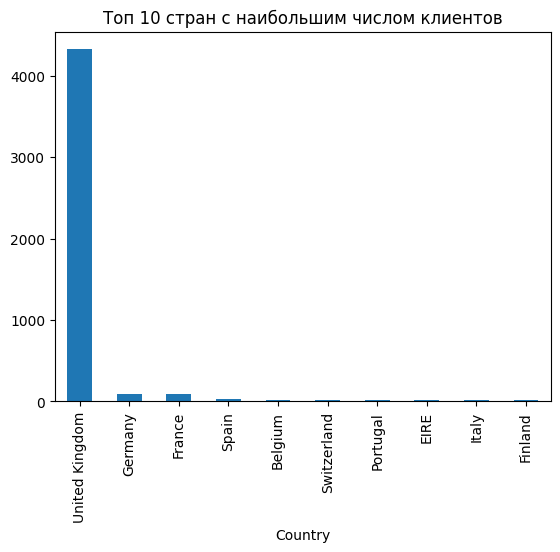

In [157]:
df.groupby('Country').agg(cnt_customers=('CustomerNo', 'nunique')).sort_values('cnt_customers', ascending=False).head(10).plot(kind='bar', legend=False)
plt.title('Топ 10 стран с наибольшим числом клиентов')

In [22]:
cancel_orders = df.groupby('TransactionNo')['is_cancelled'].first().mean() * 100

In [23]:
print(f'{np.round(cancel_orders, 2)}% заказов были отменены')

14.58% заказов были отменены


# 2. Метрики клиентов

In [24]:
df['Revenue'] = df['Price'] * df['Quantity']

In [25]:
customer_metrics = df.query('is_cancelled == False').groupby('CustomerNo', as_index=False).\
    agg(first_purchase=('Date', 'min'),
         last_purchase=('Date', 'max'),
        orders=('TransactionNo', 'nunique'),
        revenue=('Revenue', 'sum'),
        items=('Quantity', 'sum'))

In [26]:
customer_metrics.head()

,CustomerNo,first_purchase,last_purchase,orders,revenue,items
0,12004,2019-04-26,2019-04-26,1,1509.60,104
1,12006,2019-05-05,2019-05-05,1,24.76,2
2,12008,2019-03-08,2019-03-08,1,5689.57,421
3,12013,2018-12-15,2018-12-15,1,69.96,3
4,12024,2019-06-16,2019-06-16,1,149.52,14


In [27]:
customer_metrics['orders'].describe()

count    4718.000000
mean        4.194362
std         7.396101
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       207.000000
Name: orders, dtype: float64

In [28]:
repeat_customers = (customer_metrics['orders'] >= 2).sum()
total_customers = customer_metrics['CustomerNo'].nunique()
repeat_purchase_rate = np.round(repeat_customers * 100 / total_customers, 2)

In [29]:
def order_group(x):
    if x == 1:
        return '1 order'
    elif x == 2:
        return '2 orders'
    elif 2 < x <= 5:
        return '3-5 orders'
    else:
        return '6+ orders'

In [30]:
customer_metrics['order_group'] = customer_metrics['orders'].apply(order_group)

In [31]:
customer_metrics.head()

,CustomerNo,first_purchase,last_purchase,orders,revenue,items,order_group
0,12004,2019-04-26,2019-04-26,1,1509.60,104,1 order
1,12006,2019-05-05,2019-05-05,1,24.76,2,1 order
2,12008,2019-03-08,2019-03-08,1,5689.57,421,1 order
3,12013,2018-12-15,2018-12-15,1,69.96,3,1 order
4,12024,2019-06-16,2019-06-16,1,149.52,14,1 order


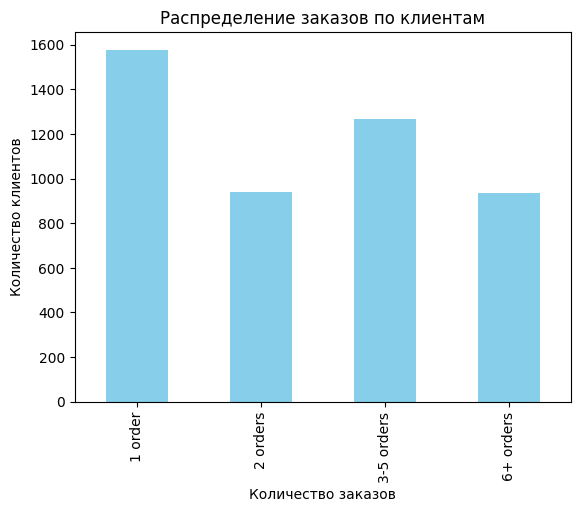

In [32]:
plt.title('Распределение заказов по клиентам')
customer_metrics['order_group'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.xlabel('Количество заказов')
plt.ylabel('Количество клиентов')
plt.show()

In [134]:
print(f'{repeat_purchase_rate}% клиентов сделали ≥2 заказа.')

66.57% клиентов сделали ≥2 заказа.


In [34]:
customer_metrics.groupby('order_group').agg(total_revenue=('revenue', 'sum'), total_items=('items', 'sum'))

,total_revenue,total_items
order_group,,
1 order,5772481.22,496235
2 orders,5738221.33,492579
3-5 orders,12129623.75,1071804
6+ orders,39140978.24,3514224


In [35]:
customer_metrics.sort_values('orders', ascending=False).head(10)

,CustomerNo,first_purchase,last_purchase,orders,revenue,items,order_group
408,12748,2018-12-01,2019-12-09,207,266515.64,25085,6+ orders
2085,14911,2018-12-01,2019-12-08,198,914204.19,80354,6+ orders
4384,17841,2018-12-01,2019-12-08,125,253038.24,22821,6+ orders
667,13089,2018-12-05,2019-12-07,98,354356.08,31065,6+ orders
2406,15311,2018-12-01,2019-12-09,91,391423.54,38077,6+ orders
1851,14606,2018-12-01,2019-12-08,90,72404.13,6169,6+ orders
581,12971,2018-12-02,2019-12-06,86,100914.98,9289,6+ orders
1880,14646,2018-12-20,2019-12-08,73,2112282.03,197420,6+ orders
918,13408,2018-12-01,2019-12-08,62,175237.05,16232,6+ orders
2978,16029,2018-12-01,2019-11-01,62,434930.14,40107,6+ orders


In [36]:
top10_ids = customer_metrics.sort_values('orders', ascending=False).head(10)['CustomerNo']

df[df['CustomerNo'].isin(top10_ids)].groupby('CustomerNo', as_index=False)['Country'].unique()

,CustomerNo,Country
0,12748,[United Kingdom]
1,12971,[United Kingdom]
2,13089,[United Kingdom]
3,13408,[United Kingdom]
4,14606,[United Kingdom]
5,14646,[Netherlands]
6,14911,[EIRE]
7,15311,[United Kingdom]
8,16029,[United Kingdom]
9,17841,[United Kingdom]


In [37]:
cm_sorted = customer_metrics.sort_values('revenue', ascending=False).reset_index(drop=True)
total_revenue = cm_sorted['revenue'].sum()
top50_revenue = cm_sorted.head(50)['revenue'].sum()
top50_share = top50_revenue * 100 / total_revenue

print(f'Топ-50 клиентов ({50 / len(cm_sorted) * 100:.1f}% от всех) дают {top50_share:.1f}% выручки')

Топ-50 клиентов (1.1% от всех) дают 30.3% выручки


In [38]:
for n in [10, 50, 100, 200]:
    share = cm_sorted.head(n)['revenue'].sum() / total_revenue * 100
    print(f'Топ-{n} ({n/len(cm_sorted)*100:.1f}%): {share:.1f}% выручки')

Топ-10 (0.2%): 15.2% выручки
Топ-50 (1.1%): 30.3% выручки
Топ-100 (2.1%): 36.9% выручки
Топ-200 (4.2%): 45.4% выручки


66.57% клиентов совершили два и более заказа. Медианное количество заказов — 2, при этом среднее составляет 4.19, что указывает на наличие группы клиентов с существенно более высокой частотой покупок. Дополнительно, 1.1% клиентов (топ-50 по выручке) формируют 30.3% всей выручки, поэтому при дальнейшем анализе retention имеет смысл отдельно учитывать наиболее ценных клиентов.

# 3. Time to Second Purchase

In [86]:
orders_dates = df.query('is_cancelled == False').groupby(['CustomerNo', 'Date', 'TransactionNo'], as_index=False)['Date'].min()
orders_dates = orders_dates.sort_values(['CustomerNo', 'Date', 'TransactionNo'])
orders_dates['order_rank'] = orders_dates.groupby('CustomerNo').cumcount() + 1

In [87]:
df_first_two = orders_dates[orders_dates['order_rank'].isin([1, 2])].copy()

In [88]:
df_first_two['days_between'] = df_first_two.groupby('CustomerNo')['Date'].diff().dt.days

In [89]:
df_first_two.dropna()['days_between'].describe()

count    3141.000000
mean       82.334607
std        79.444808
min         0.000000
25%        22.000000
50%        56.000000
75%       120.000000
max       368.000000
Name: days_between, dtype: float64

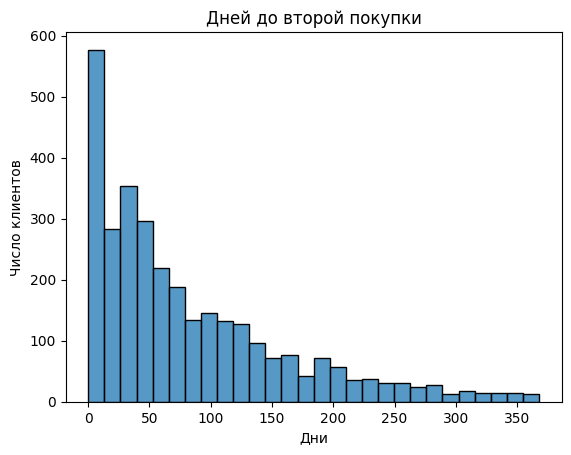

In [90]:
sns.histplot(df_first_two.dropna()['days_between'])
plt.title('Дней до второй покупки')
plt.xlabel('Дни')
plt.ylabel('Число клиентов')
plt.show()

Среди клиентов, сделавших повторную покупку, медианное время до второго заказа — 56 дней. Разброс большой: у 25% клиентов второй заказ происходит уже в течение 22 дней, а у четверти — только через 120+ дней. Среднее (82 дня) заметно выше медианы — распределение скошено вправо за счёт "долгих" повторов. Метрика посчитана только по тем, кто уже вернулся; часть клиентов из поздних когорт могла не успеть сделать второй заказ к концу периода данных — соответственно, реальное медианное время может быть немного выше.

# 4. Cohort Retention

In [82]:
def get_retention(data):
    
    df = data.query('is_cancelled == False').copy()
    
    df['order_month'] = df['Date'].dt.to_period('M')
    
    df['cohort_month'] = df.groupby('CustomerNo')['Date'].transform('min').dt.to_period('M')
    
    df['cohort_index'] = (df['order_month'] - df['cohort_month']).apply(lambda x: x.n)

    cohort_data = df.groupby(['cohort_month', 'cohort_index'], as_index=False)['CustomerNo'].nunique()

    cohort_counts = cohort_data.pivot_table(index='cohort_month', columns='cohort_index', values='CustomerNo')

    cohort_size = cohort_counts[0]
    
    retention = cohort_counts.divide(cohort_size, axis=0)

    return retention

Text(120.72222222222221, 0.5, 'Когорта')

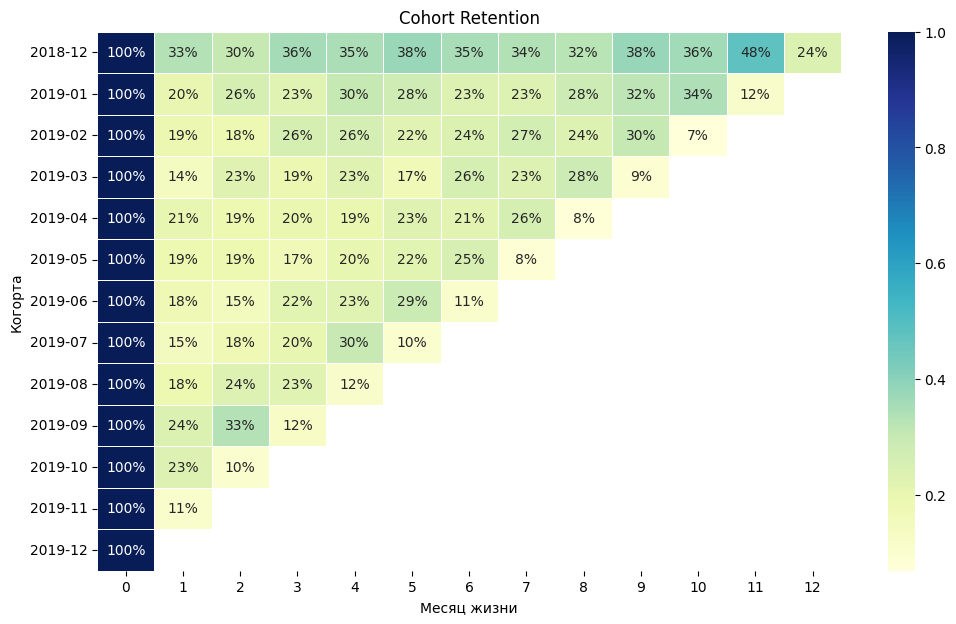

In [136]:
plt.figure(figsize=(12,7))
sns.heatmap(get_retention(df), annot=True, fmt='.0%', cmap='YlGnBu',\
    linewidths=0.5)
plt.title('Cohort Retention')
plt.xlabel('Месяц жизни')
plt.ylabel('Когорта')

В большинстве зрелых когорт retention после первого месяца находится примерно в диапазоне 14–24%, то есть значительная часть клиентов не совершает повторную покупку в течение следующего месяца.

# 5. Первая покупка → Повторная покупка
Задача: понять, отличаются ли характеристики первого заказа у тех, кто вернулся, и у тех, кто нет.

In [97]:
first_order_tx = orders_dates.loc[orders_dates['order_rank'] == 1, ['CustomerNo', 'TransactionNo', 'Date']]
first_order_items = df.merge(first_order_tx, on=['CustomerNo', 'TransactionNo'], suffixes=('', '_first'))

In [178]:
first_order_stats = first_order_items.groupby('CustomerNo', as_index=False).\
    agg(first_order_revenue=('Revenue', 'sum'),
        first_order_items=('Quantity', 'sum'),
        first_order_unique_products=('ProductNo', 'nunique'),
        first_order_country=('Country', 'first'))

In [179]:
first_order_stats['first_order_month'] = (
    first_order_stats['CustomerNo']
    .map(first_order_tx.set_index('CustomerNo')['Date'].dt.to_period('M'))
)

In [180]:
first_order_stats.head()

,CustomerNo,first_order_revenue,first_order_items,first_order_unique_products,first_order_country,first_order_month
0,12004,1509.60,104,56,United Kingdom,2019-04
1,12006,24.76,2,1,United Kingdom,2019-05
2,12008,5689.57,421,203,United Kingdom,2019-03
3,12013,69.96,3,1,United Kingdom,2018-12
4,12024,149.52,14,5,United Kingdom,2019-06


In [142]:
customer_metrics['returned'] = customer_metrics['orders'] >= 2

In [143]:
analysis_df = first_order_stats.merge(customer_metrics[['CustomerNo', 'returned']], on='CustomerNo')

In [144]:
analysis_df.groupby('returned')[['first_order_revenue', 'first_order_items', 'first_order_unique_products']].median()

,first_order_revenue,first_order_items,first_order_unique_products
returned,,,
False,1578.26,136.0,17.0
True,1786.71,148.0,18.0


In [121]:
median_diff = 1786.71 - 1578.26
relative_diff = median_diff / 1578.26 * 100
print(f'Разница медиан: {median_diff:.0f} ({relative_diff:.1f}%)')

Разница медиан: 208 (13.2%)


Медианная сумма первой покупки у вернувшихся клиентов выше на 208. Проверим, несет ли данная разница статистическую значимость.

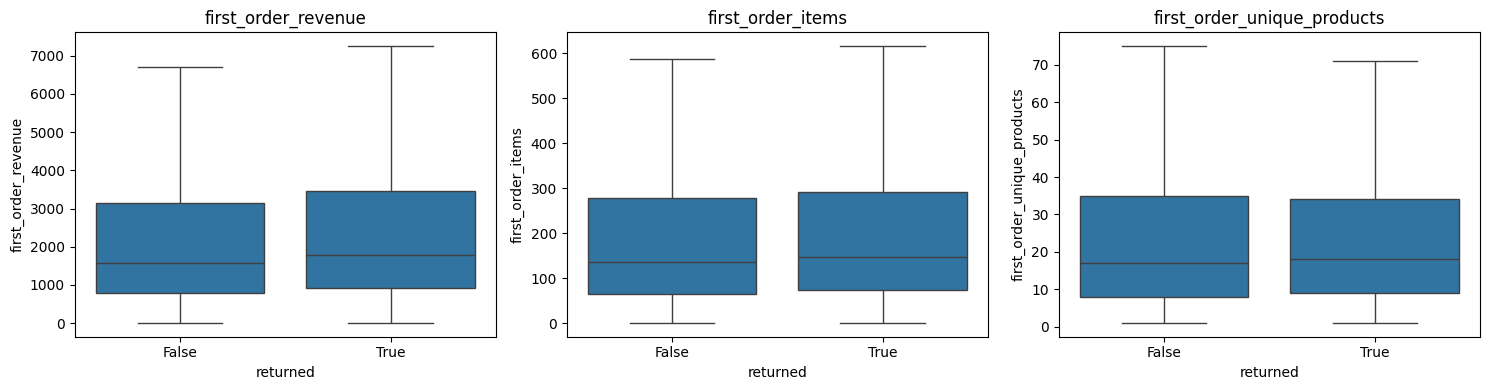

In [110]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['first_order_revenue', 'first_order_items', 'first_order_unique_products']):
    sns.boxplot(x='returned', y=col, data=analysis_df, ax=ax, showfliers=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [113]:
returned_rev = analysis_df.loc[analysis_df['returned'], 'first_order_revenue']
not_returned_rev = analysis_df.loc[~analysis_df['returned'], 'first_order_revenue']

stat, p = stats.mannwhitneyu(returned_rev, not_returned_rev, alternative='two-sided')
print(f'p-value: {p:.4f}')

p-value: 0.0001


Тест Манна–Уитни показал статистически значимое различие в распределении выручки первой покупки между клиентами, совершившими и не совершившими повторную покупку (p = 0.0001). Медианная выручка первой покупки у вернувшихся клиентов составляет 1,786.71 против 1,578.26 у клиентов без повторной покупки — разница около 13.2%. Результат показывает наличие связи между размером первой покупки и последующим повторным поведением, но не доказывает причинно-следственную связь.

**Гипотеза**: клиенты с более крупной и разнообразной первой покупкой могут иметь более высокую вероятность повторного заказа. Это может быть связано с типом клиента, ассортиментом или сценарием использования продукта и требует дополнительной проверки.

In [130]:
country_stats = analysis_df.groupby('first_order_country', as_index=False).\
    agg(customers=('CustomerNo', 'nunique'),
        return_rate=('returned', 'mean')).\
        query('customers >= 30').sort_values('return_rate', ascending=False)

In [131]:
country_stats['return_rate'] = (country_stats['return_rate'] * 100).round(1)

In [132]:
country_stats

,first_order_country,customers,return_rate
13,France,87,74.7
14,Germany,91,73.6
36,United Kingdom,4305,66.6


Во Франции и Германии наблюдается более высокий observed return rate, чем в UK, однако размеры групп существенно различаются (87, 91 и 4,305 клиентов соответственно), поэтому различия требуют дополнительной проверки на более стабильной выборке.

Text(0.5, 1.0, 'Доля вернувшихся клиентов')

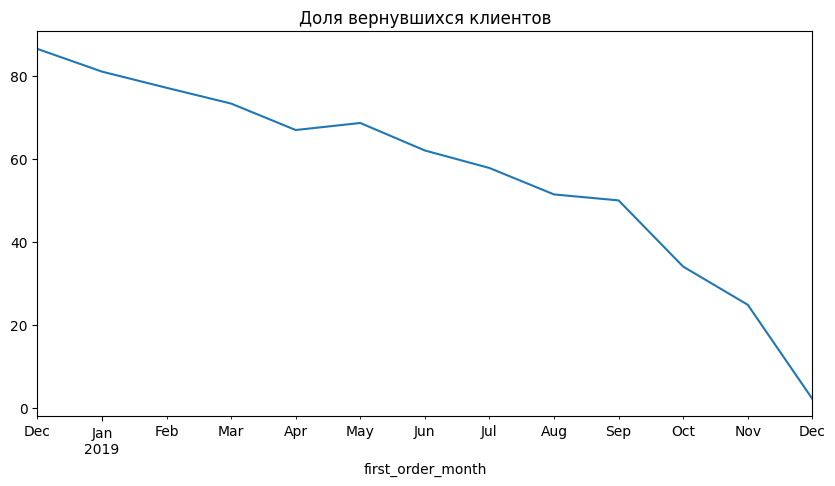

In [162]:
plt.figure(figsize=(10,5))
(analysis_df.groupby('first_order_month')['returned'].mean() * 100).plot(kind='line')
plt.title('Доля вернувшихся клиентов')

Доля вернувшихся клиентов снижается по месяцу первой покупки. Часть этого тренда всё ещё объясняется сокращающимся окном наблюдения (у более поздних когорт меньше времени на второй заказ), а не однозначно ухудшением поведения клиентов.

# 6. RFM-сегментация

In [283]:
snapshot_date = df['Date'].max() + pd.Timedelta(days=1)

In [284]:
rfm = customer_metrics[['CustomerNo', 'last_purchase', 'orders', 'revenue']].copy()
rfm['recency'] = (snapshot_date - rfm['last_purchase']).dt.days
rfm = rfm.rename(columns={'orders': 'frequency', 'revenue': 'monetary'})
rfm[['recency', 'frequency', 'monetary']].describe()

,recency,frequency,monetary
count,4718.000000,4718.000000,4.718000e+03
mean,96.992794,4.194362,1.330676e+04
std,101.758271,7.396101,5.437039e+04
min,1.000000,1.000000,5.970000e+00
25%,19.000000,1.000000,1.829763e+03
50%,54.000000,2.000000,4.804425e+03
75%,156.750000,5.000000,1.183031e+04
max,374.000000,207.000000,2.112282e+06


In [285]:
rfm

,CustomerNo,last_purchase,frequency,monetary,recency
0,12004,2019-04-26,1,1509.60,228
1,12006,2019-05-05,1,24.76,219
2,12008,2019-03-08,1,5689.57,277
3,12013,2018-12-15,1,69.96,360
4,12024,2019-06-16,1,149.52,177
...,...,...,...,...,...
4713,18280,2019-03-07,1,623.26,278
4714,18281,2019-06-12,1,576.58,181
4715,18282,2019-12-02,2,1044.86,8
4716,18283,2019-12-06,16,11773.90,4


In [286]:
rfm['R'] = pd.qcut(rfm['recency'], 4, labels=[4, 3, 2, 1])
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M'] = pd.qcut(rfm['monetary'], 4, labels=[1, 2, 3, 4])

In [287]:
rfm['RFM_score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

In [288]:
rfm.head()

,CustomerNo,last_purchase,frequency,monetary,recency,R,F,M,RFM_score
0,12004,2019-04-26,1,1509.60,228,1,1,1,111
1,12006,2019-05-05,1,24.76,219,1,1,1,111
2,12008,2019-03-08,1,5689.57,277,1,1,3,113
3,12013,2018-12-15,1,69.96,360,1,1,1,111
4,12024,2019-06-16,1,149.52,177,1,1,1,111


In [291]:
def segment(row):
    r, f, m = int(row['R']), int(row['F']), int(row['M'])
    if r >= 4 and f >= 4 and m >= 4:
        return 'VIP'
    elif r >= 3 and f >= 3:
        return 'Лояльные'
    elif r >= 4 and f <= 2:
        return 'Новички'
    elif r <= 2 and m >= 3:
        return 'Дремлющие крупные'
    elif r <= 2 and f >= 3:
        return 'В зоне риска'
    elif r == 1:
        return 'Потерянные'
    else:
        return 'Прочие'
rfm['segment'] = rfm.apply(segment, axis=1)

In [292]:
segment_summary = rfm.groupby('segment').agg(customers=('CustomerNo', 'count'),
                           total_revenue=('monetary', 'sum'),
                           avg_recency=('recency', 'mean'),
                           avg_frequency=('frequency', 'mean'))

In [293]:
segment_summary['revenue_share'] = (segment_summary['total_revenue'] / segment_summary['total_revenue'].sum() * 100).round(1)
segment_summary['customers_share'] = (segment_summary['customers'] / segment_summary['customers'].sum() * 100).round(1)
segment_summary.sort_values('total_revenue', ascending=False)

,customers,total_revenue,avg_recency,avg_frequency,revenue_share,customers_share
segment,,,,,,
VIP,499,28722223.27,7.993988,15.364729,45.7,10.6
Лояльные,1163,15746078.06,23.946690,5.248495,25.1,24.7
Дремлющие крупные,825,11355543.88,134.106667,3.232727,18.1,17.5
Прочие,900,3095696.77,65.224444,1.361111,4.9,19.1
Новички,263,1894487.48,10.813688,1.555133,3.0,5.6
Потерянные,840,1318527.22,263.151190,1.166667,2.1,17.8
В зоне риска,228,648747.86,142.728070,3.232456,1.0,4.8


In [294]:
top50_ids = customer_metrics.sort_values('revenue', ascending=False).head(50)['CustomerNo']
rfm[rfm['CustomerNo'].isin(top50_ids)]['segment'].value_counts()

segment
VIP                  36
Лояльные              8
Дремлющие крупные     3
Прочие                2
Новички               1
Name: count, dtype: int64

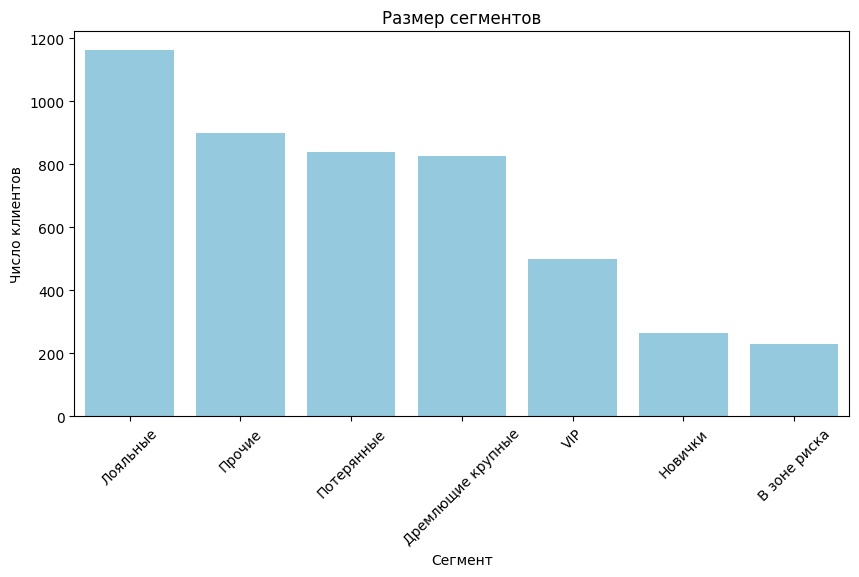

In [295]:
plt.figure(figsize=(10, 5))
sns.barplot(segment_summary.sort_values('customers', ascending=False), x='segment', y='customers', color='skyblue')
plt.title('Размер сегментов')
plt.xlabel('Сегмент')
plt.ylabel('Число клиентов')
plt.xticks(rotation=45)
plt.show()

VIP-сегмент (10,6% клиентов) формирует 45,7% выручки — почти половину. Сегмент "Дремлющие крупные" представляет значительный объём потенциально возвращаемой ценности: 17.5% клиентов исторически формируют 18.1% выручки и имеют среднюю давность последней покупки 134 дня. Поэтому этот сегмент можно рассматривать как отдельную аудиторию для тестирования реактивационных кампаний. Сегмент "В зоне риска" (частые покупатели, давно не заказывавшие, но с невысоким чеком) оказался небольшим — 4,8% клиентов, 1% выручки, — основной риск для бизнеса сосредоточен именно в "дремлющих крупных", а не в этой группе.
Для "дремлющих крупных" клиентов (17,5% базы / 18,1% выручки, средняя неактивность 134 дня) стоит протестировать персонализированную реактивационную кампанию — например, персональное предложение или контакт менеджера — отдельно от массовых email-рассылок, ориентированных на "Потерянных" и "Прочих".

# 7. Анализ отмен заказов

In [298]:
order_level = df.groupby(['TransactionNo', 'Country'], as_index=False)['is_cancelled'].first()

In [305]:
country_cancel = order_level.groupby('Country', as_index=False).agg(orders=('TransactionNo', 'nunique'), cancelled_orders=('is_cancelled', 'sum'))
country_cancel['cancel_rate'] = (country_cancel['cancelled_orders'] * 100 / country_cancel['orders']).round(1)
country_cancel = country_cancel.query('orders >= 30').sort_values('cancel_rate', ascending=False)

In [347]:
country_cancel.head()

,Country,orders,cancelled_orders,cancel_rate
19,Italy,42,12,28.6
33,Switzerland,73,18,24.7
14,Germany,587,134,22.8
32,Sweden,41,8,19.5
10,EIRE,332,55,16.6


Наблюдаемая доля отмен по странам вне UK основана на небольших выборках, поэтому различия могут частично объясняться случайностью. Требуется проверка статистическим методом.

In [335]:
product_order_level = df.groupby(['TransactionNo', 'ProductNo'], as_index=False).agg(
    product_name=('ProductName', 'first'),
    is_cancelled=('is_cancelled', 'first')
)

product_cancel = product_order_level.groupby('ProductNo', as_index=False).agg(
    product_name=('product_name', 'first'),
    orders=('TransactionNo', 'nunique'),
    cancelled_orders=('is_cancelled', 'sum')
)
product_cancel['cancel_rate'] = (product_cancel['cancelled_orders'] * 100 / product_cancel['orders']).round(1)
product_cancel = product_cancel.query('orders >= 30')

In [341]:
product_cancel.sort_values('cancel_rate', ascending=False).head(10)

,ProductNo,product_name,orders,cancelled_orders,cancel_rate
1909,23064,Cinderella Chandelier,33,10,30.3
2278,23462,Rococo Wall Mirror White,58,12,20.7
1335,22461,Savoy Art Deco Clock,65,12,18.5
3318,85159B,White Tea Coffee Sugar Jars,72,13,18.1
1518,22655,Vintage Red Kitchen Cabinet,46,8,17.4
2453,35004C,Set Of 3 Coloured Flying Ducks,47,8,17.0
2794,79191C,Retro Plastic Elephant Tray,78,13,16.7
968,22060,Large Cake Stand Hanging Hearts,40,6,15.0
1098,22198,Large Popcorn Holder,101,15,14.9
2555,37449,Ceramic Cake Stand + Hanging Cakes,179,25,14.0


In [344]:
order_month_level = df.groupby('TransactionNo', as_index=False).agg(
    is_cancelled=('is_cancelled', 'first'),
    order_month=('order_month', 'first')
)
monthly_cancel = order_month_level.groupby('order_month', as_index=False)['is_cancelled'].mean()
monthly_cancel['is_cancelled'] = (monthly_cancel['is_cancelled'] * 100).round(1)

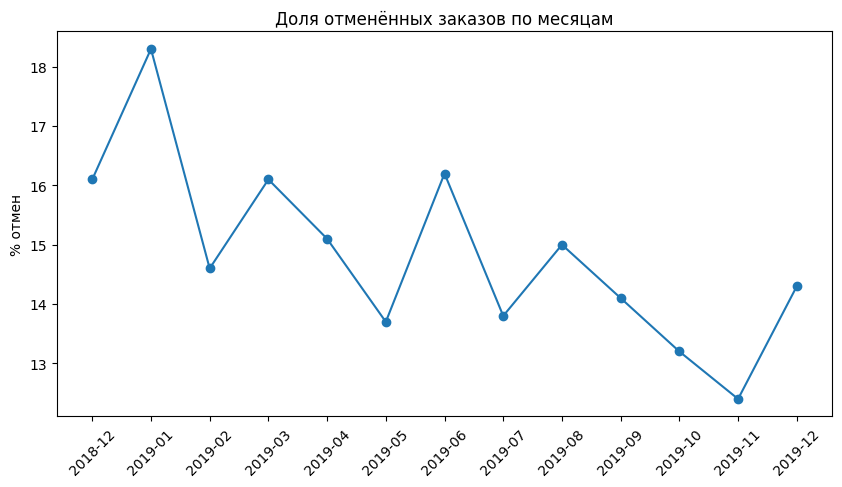

In [351]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_cancel['order_month'].astype(str), monthly_cancel['is_cancelled'], marker='o')
plt.xticks(rotation=45)
plt.title('Доля отменённых заказов по месяцам')
plt.ylabel('% отмен')
plt.show()

Проведем тест хи-квадрат, чтобы убедится в том, что доля отмен в странах вызвана реальным эффектом, а не случайностью.

In [350]:
all_countries = country_cancel['Country'] 
table_full = pd.crosstab(
    order_level[order_level['Country'].isin(all_countries)]['Country'],
    order_level[order_level['Country'].isin(all_countries)]['is_cancelled']
)
chi2, p, dof, expected = chi2_contingency(table_full)
print(f'p-value: {p:.4f}')

p-value: 0.0000


Тест χ² показал статистически значимую связь между страной и фактом отмены заказа (p < 0.0001). Причина различий между странами не может быть определена по имеющимся данным.

Среди товаров наиболее высокая доля отмены приходится на отдельные декоративные и товары для дома; например, Cinderella Chandelier — 30.3%.

По месяцам устойчивого сезонного тренда не выявлено; локальный пик в январе 2019 (18,3%) и минимум в ноябре 2019 (12,4%) не образуют явной закономерности.

# 8. Ключевые выводы и гипотезы о продукте

1. Выручка сильно сконцентрирована в узком сегменте клиентов
Топ-50 клиентов (1,1% базы) формируют 30,3% выручки. VIP-сегмент по RFM (10,6% клиентов) — 45,7% выручки.
→ Гипотеза: выделить персональный сервис/менеджера для VIP-сегмента; ключевые метрики удержания отслеживать для него отдельно от массовой базы — потеря даже нескольких клиентов из этой группы даёт непропорциональный удар по выручке.

2. Наибольшее снижение retention наблюдается в первый месяц после первой покупки.
В доступных когортах не наблюдается устойчивого улучшения retention со временем, однако сравнение поздних когорт ограничено меньшим периодом наблюдения.
→ Гипотеза: приоритет — улучшение onboarding/повторного касания в первые 2-4 недели после первой покупки (например, персонализированное письмо), а не работа с давно ушедшими клиентами.

4. Есть отдельный сегмент "дремлющих крупных" клиентов
17,5% клиентов не покупали в среднем 134 дня, но исторически дают 18,1% выручки — их ценность уже доказана, просто активность упала.
→ Гипотеза: точечная реактивационная кампания (персональное предложение) для этого сегмента отдельно от массовых рассылок — конверсия здесь ожидаемо выше, чем у случайных "потерянных" клиентов.

5. Медианное время до второй покупки — 56 дней
25% вернувшихся клиентов делают это уже в течение 22 дней, у остальных — дольше, вплоть до нескольких месяцев.
→ Гипотеза: установить окно ~30-45 дней как триггер для автоматической реактивационной коммуникации — если клиент не вернулся органически к этому сроку, вероятность органического повтора начинает падать.

6. Доля отмен статистически различается между странами (χ², p < 0.0001). Наиболее высокие значения наблюдаются в Italy, Switzerland и Germany. Однако имеющиеся данные не позволяют определить причину различий.